<a href="https://colab.research.google.com/github/kangmg/mlip_numerical_instability/blob/main/numerical_stability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os

uma_small_path = 'uma-s-1.1.pt'
assert os.path.exists(uma_small_path), "uma model is not found !"

In [ ]:
!wget https://github.com/ACEsuit/mace-foundations/releases/download/mace_omol_0/MACE-omol-0-extra-large-1024.model

--2025-11-12 16:33:59--  https://github.com/ACEsuit/mace-foundations/releases/download/mace_omol_0/MACE-omol-0-extra-large-1024.model
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/741903654/a9fcc9c5-b981-463f-a940-d9069cf1a706?sp=r&sv=2018-11-09&sr=b&spr=https&se=2025-11-12T17%3A30%3A34Z&rscd=attachment%3B+filename%3DMACE-omol-0-extra-large-1024.model&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2025-11-12T16%3A30%3A25Z&ske=2025-11-12T17%3A30%3A34Z&sks=b&skv=2018-11-09&sig=F2VnNXX9hrlQ38ICVJaAclCgxrYaA%2BNLasFrqJhf%2F4k%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc2Mjk2ODgzOSwibmJmIjoxNz

In [ ]:
#@title Install Required Packages & Reboot
#@markdown `Excute this cell only one time`
!uv pip install ase -q
!uv pip install fairchem-core -q
!uv pip install orb-models -q
!uv pip install git+https://github.com/kangmg/aseview.git -q
!uv pip install mace-torch -q
!uv pip install sella -q

# restart kernal
import os
os._exit(00)

In [ ]:
#@title test molecule xyz file
%%writefile test_molecule.xyz
97

Mn   -1.64979274  -3.63156284   3.20218332
O    -0.15814473   0.42757127   0.46601931
O    -3.50273079  -8.45739739   2.08524267
O    -1.12895771  -1.98538907   5.63501759
O    -2.91911467  -1.86147202   1.23567558
O    -4.42546104  -3.90252865   4.11211611
N     0.46400422  -3.32302008   2.95933663
N    -0.87150791  -5.58588680   3.51971776
C     1.10810861  -2.15734886   2.75562074
C     2.49011203  -2.05226738   2.83694545
C     3.27312432  -3.14866514   3.16550275
C     2.59308933  -4.32935189   3.41710802
C     1.21038661  -4.39385235   3.30322347
C     0.47604439  -5.65394291   3.53668307
C     1.17209060  -6.85031672   3.70393047
C     0.49596468  -8.04200733   3.84013182
C    -0.89556158  -7.96233524   3.81758430
C    -1.54691658  -6.75598912   3.66243796
C     4.79158691  -3.10068736   3.26298873
C     1.18704612  -9.39422964   3.92779638
C     0.31851586  -0.91027359   2.46928197
C     0.87018019  -0.06628248   1.30733716
C    -3.05259238  -6.70834777   3.63630567
C    -3.77315140  -8.01761951   3.41029954
C    -1.34927608  -2.68322541   4.74765957
C    -2.35663269  -2.53928075   2.00793511
C    -3.34145686  -3.85666240   3.71300951
C     5.21927411  -3.49547370   4.68332695
H     4.80016088  -2.80900566   5.42087572
H     4.89391221  -4.50461621   4.93879215
H     6.30740975  -3.46403073   4.76512548
C     5.38306022  -4.09529562   2.25337615
H     5.09052644  -3.83520826   1.23422953
H     6.47311081  -4.07923724   2.31105468
H     5.05076393  -5.11554440   2.44980812
C     5.34229740  -1.70842835   2.95599805
H     5.08492043  -1.38598744   1.94519814
H     4.97298670  -0.96343820   3.66320074
H     6.43044773  -1.72503812   3.03105622
C     2.70883811  -9.25841267   3.95583107
H     3.08386205  -8.78911663   3.04412093
H     3.04544969  -8.67604349   4.81631294
H     3.15974736 -10.24919150   4.02960628
C     0.79484800 -10.21591852   2.69012718
H     1.27824012 -11.19447326   2.72455324
H    -0.28381684 -10.37431380   2.63848472
H     1.11017366  -9.70525894   1.77793297
C     0.73089633 -10.12060356   5.19978222
H     0.99372195  -9.54760814   6.09082750
H    -0.34763517 -10.28297023   5.20940941
H     1.21604069 -11.09641096   5.26466543
H    -3.48270959  -8.79569692   4.12679558
H    -4.85079437  -7.85597081   3.52921025
H    -3.35855084  -6.02073646   2.84909700
H    -3.41191140  -6.26704326   4.56835226
H     2.24677543  -6.85093817   3.66089076
H    -1.48181073  -8.86604424   3.88854687
H     1.50401812  -0.67342989   0.65935798
H     1.47149519   0.77575270   1.67121657
H    -0.70269857  -1.18551703   2.23787134
H     0.26796512  -0.32416829   3.39149176
H     2.93848484  -1.08556914   2.65631019
H     3.14893447  -5.20470960   3.71184542
C    -1.02398608   1.34883972   1.10790879
H    -0.45071615   2.18323220   1.52579064
H    -1.70794283   1.72429008   0.35114257
H    -1.60504051   0.87182530   1.90049681
C    -4.07692237  -9.72114181   1.80946027
H    -3.85042589  -9.96501715   0.77404398
H    -3.65444021 -10.49086466   2.46400952
H    -5.16296372  -9.69918391   1.94511777
N    -1.26414861  -4.86996545   0.21308260
C    -1.42126586  -3.75348392  -0.74465985
H    -2.37384836  -3.26571626  -0.55439450
H    -1.43056092  -4.16326873  -1.76097667
C    -2.30526598  -5.89191292   0.01583280
H    -2.15617719  -6.66600474   0.76994071
H    -2.18408158  -6.35104466  -0.97169709
C     0.10054266  -5.43688237   0.11009342
H     0.76487043  -4.83229595   0.72883469
H     0.43153724  -5.33703114  -0.93088510
C    -0.32808843  -2.70217730  -0.61011431
H     0.64746327  -3.10795586  -0.89885991
H    -0.26453281  -2.40132361   0.43732868
C     0.26787600  -6.89723797   0.51594938
H    -0.22471449  -7.56604521  -0.19510076
H    -0.15291199  -7.09407403   1.49713168
C    -3.73623321  -5.38888935   0.16249851
H    -4.03179885  -4.76128096  -0.67718365
H    -3.83540813  -4.79117665   1.07546290
O    -0.64523790  -1.61644258  -1.45046217
O     1.65344434  -7.20065853   0.60807201
O    -4.60523826  -6.50563865   0.15482834
H    -0.64918817  -0.81292448  -0.90649971
H     2.03159907  -7.19924282  -0.27726293
H    -4.30455036  -7.12828453   0.83550852
H    -1.50272010  -4.30993474   1.39827034


Writing test_molecule.xyz


In [ ]:
#@title calculation utils
from tqdm.notebook import tqdm
from ase.vibrations import Vibrations, VibrationsData
# from dmf import DirectMaxFlux, interpolate_fbenm
from typing import Union, Optional, List
from ase.io import write, Trajectory
# from ase.mep.autoneb import AutoNEB
# from ase.optimize import FIRE, BFGS
# from ase.mep.neb import NEBOptimizer
# from ase.mep import NEB, DyNEB
from sella import Sella #, IRC
from io import StringIO
import os
import numpy as np
from ase import io
from orb_models.forcefield import pretrained
from orb_models.forcefield.calculator import ORBCalculator
import torch
from fairchem.core import pretrained_mlip, FAIRChemCalculator
from mace.calculators import mace_omol
from mace.calculators import MACECalculator
import ase
from ase import Atoms

predictor_cache = {}

model_name = "UMA-S" # @@param ["UMA-S","OrbMol", "MACE-OMOL"]

def calc_attach(method=None, dtype=None):
    """
    Returns a function that attaches an ASE-compatible calculator to one or more Atoms objects.

    Parameters:
        method (str): The name of the method to use. Must be one of:
                      'UMA-S', 'OrbMol', 'MACE-OMOL'.

    Returns:
        Callable[[ase.Atoms or Iterable[ase.Atoms]], None]: A function that modifies
        one or more Atoms objects in-place by attaching the appropriate calculator.

    Raises:
        AssertionError: If the specified method is not supported.

    Example:
        >>> atoms = molecule('H2O')
        >>> calc_attach("UMA-S")(atoms)

        >>> images = [molecule('H2O'), molecule('CO2')]
        >>> calc_attach("OrbMol")(images)
    """
    global predictor_cache

    allowed_methods = {"UMA-S", "OrbMol", "MACE-OMOL"}
    assert method in allowed_methods, \
        f"[calc_attach] Invalid method '{method}'. Choose from: {allowed_methods}"

    def _attach_fn(images, **atoms_info):
        """
        Attach calculator to a single ASE Atoms object or an iterable of them.
        """
        def attach_single(atoms):
            # update charge/spin
            if atoms_info:
                atoms.info.update(atoms_info)
            device = 'cuda' if torch.cuda.is_available() else 'cpu'

            if method == "UMA-S":
                if dtype:
                    raise NotImplementedError("dtype is not supported for UMA")
                if "UMA-S" not in predictor_cache:
                    path = 'uma-s-1.1.pt'
                    predictor = pretrained_mlip.load_predict_unit(path, device=device)
                    #predictor.model = predictor.model.to(torch.float32)
                    predictor_cache["UMA-S"] = predictor
                atoms.calc = FAIRChemCalculator(predictor_cache["UMA-S"], task_name="omol")

            elif method == "OrbMol":
                supported_dtype = ["float64", "float32-highest", "float32-high"]
                method_dtype = f"{method}_{dtype}"
                assert dtype in supported_dtype, f"OrbMol supported dtype: \n{supported_dtype}"
                if method_dtype not in predictor_cache:
                    predictor_cache[method_dtype] = pretrained.orb_v3_conservative_omol(
                        device=device,
                        precision=dtype,
                        )
                atoms.calc = ORBCalculator(predictor_cache[method_dtype], device=device)

            elif method == "MACE-OMOL":
                supported_dtype = ["float64", "float32"]
                method_dtype = f"{method}_{dtype}"
                assert dtype in supported_dtype, f"MACE-OMOL supported dtype: \n{supported_dtype}"
                if 'MACE-OMOL' not in predictor_cache:
                    predictor_cache[method_dtype] = mace_omol(
                        #model="extra_large",
                        model="MACE-omol-0-extra-large-1024.model",
                        device=device,
                        return_raw_model=True
                        )
                atoms.calc = MACECalculator(
                    models=predictor_cache[method_dtype],
                    device=device,
                    head="omol",
                    default_dtype=dtype
                    )


        if isinstance(images, ase.Atoms):
            attach_single(images)
        else:
            try:
                for atoms in images:
                    attach_single(atoms)
            except Exception as e:
                print(f"Fail to attch calculator to {images}")
                print(e)

    return _attach_fn


def freq_analysis(atoms: ase.Atoms, vib_name: str, attach_calculator=None,):
    """
    Calculate vibrational frequencies and validate the stationary point (minimum or TS).

    Parameters:
    -----------
    atoms : ase.Atoms
        The optimized Atoms object (local minimum or transition state).
        Must have a calculator attached.
    vib_name : str
        Name for hessian npy data & Vibrations data folder
    attach_calculator : callable, optional
        Function to attach calculator to atoms if needed

    Returns:
    --------
    Vibrations
    """
    # Attach calculator if needed
    if not atoms.calc and attach_calculator:
        attach_calculator(atoms)
    elif not atoms.calc and not attach_calculator:
        raise ValueError("No Calculator provided")

    vib_data = Vibrations(atoms, delta=0.01, name=vib_name)
    vib_data.run()
    # frequencies = vib_data.get_frequencies()
    # hessian_2d = vib_data.get_vibrations().get_hessian_2d()

    # # Check for imaginary frequencies
    # imaginary_freqs = frequencies[frequencies < -1e-5]
    # num_imaginary = len(imaginary_freqs)

    return vib_data


def sella_optimize(
    atoms: ase.Atoms,
    attach_calculator: Optional[callable] = None,
    fmax: float = 0.05,
    steps: int = 200,
    logfile: Optional[str] = None,
    trajectory: Optional[str] = 'opt.traj',
    **kwargs
    ) -> ase.Atoms:
    """
    Perform geometry optimization using a specified ASE optimizer (e.g., FIRE, BFGS)
    or Sella for TS optimization.

    Parameters:
    -----------
    atoms : ase.Atoms
        The initial structure to optimize. Must have a calculator attached.
    fmax : float, default=0.05
        Convergence criterion for maximum force (eV/Å).
    steps : int, default=200
        Maximum number of optimization steps.
    logfile : str, optional
        Path to the log file.
    trajectory : str, optional
        Path to the trajectory file to save optimization steps.
    **kwargs :
        Additional arguments passed to the optimizer.

    Returns:
    --------
    ase.Atoms
        The optimized structure.
    """
    if not atoms.calc and attach_calculator:
        attach_calculator(atoms)
    elif not atoms.calc:
        raise ValueError("No Calculator provided")

    opt = Sella(atoms, order=1, logfile=logfile, trajectory=trajectory, **kwargs)

    converged = opt.run(fmax=fmax, steps=steps)

    if not converged:
        print(f"!! TS Optimization Faild !!")
        return atoms

    write(
        f"{atoms.info.get('name', 'TS')}_optimized.xyz",
        atoms,
        format='xyz')
    return atoms


def generate_mode_traj(atoms: Atoms, mode_vector: np.ndarray,
                       filename: str = 'mode_traj.traj',
                       amp: float = 0.1,
                       n_frames: int = 81) -> None:
    """
    Generate a trajectory file for ASE Atoms object by displacing along a vibrational mode vector.
    The displacement amplitude linearly varies from start_amp to end_amp over n_frames.

    Parameters:
    -----------
    atoms : ase.Atoms
        The reference ASE Atoms object.
    mode_vector : np.ndarray
        The vibrational mode vector (displacements), shape (n_atoms, 3).
    filename : str, optional
        Output trajectory filename (default: 'mode_traj.traj').
    start_amp : float, optional
        Starting amplitude multiplier for the mode vector (default: 0.1).
    end_amp : float, optional
        Ending amplitude multiplier for the mode vector (default: -0.1).
    n_frames : int, optional
        Number of frames in the trajectory (default: 81).

    Notes:
    ------
    - Assumes mode_vector is in the same units as positions (e.g., Ångstroms).
    - The trajectory is written in ASE's Trajectory format (supports XYZ, TRAJ, etc., via ase.io).
    - No unit cell or other properties are modified; only positions are displaced.
    """
    n_atoms = len(atoms)
    assert mode_vector.shape == (n_atoms, 3), f"Mode vector shape mismatch: expected ({n_atoms}, 3), got {mode_vector.shape}"

    amplitudes = np.linspace(-amp, amp, n_frames)

    with Trajectory(filename, 'w') as traj:
        for amp in amplitudes:
            displaced_atoms = atoms.copy()
            displaced_atoms.positions += amp * mode_vector
            traj.write(displaced_atoms)

/usr/local/lib/python3.12/dist-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))


cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.


In [ ]:
from ase.io import read

atoms = read('test_molecule.xyz', format='xyz')

# calc_attach('UMA-S')(atoms, spin=1, charge=0)
# calc_attach('OrbMol', 'float32-highest')(atoms, spin=1, charge=0)
# calc_attach('OrbMol', 'float32-high')(atoms, spin=1, charge=0)
# calc_attach('OrbMol', 'float64')(atoms, spin=1, charge=0)
# calc_attach('MACE-OMOL', 'float32')(atoms, spin=1, charge=0)
# calc_attach('MACE-OMOL', 'float64')(atoms, spin=1, charge=0)

In [ ]:
#@title ts_optimize structure
%%writefile ts_opt.xyz
97

Mn     -1.649792740000000     -3.631562840000000      3.202183320000000
O      -0.158144730000000      0.427571270000000      0.466019310000000
O      -3.502730790000000     -8.457397390000001      2.085242670000000
O      -1.128957710000000     -1.985389070000000      5.635017590000000
O      -2.919114670000000     -1.861472020000000      1.235675580000000
O      -4.425461040000000     -3.902528650000000      4.112116110000000
N       0.464004220000000     -3.323020080000000      2.959336630000000
N      -0.871507910000000     -5.585886800000000      3.519717760000000
C       1.108108610000000     -2.157348860000000      2.755620740000000
C       2.490112030000000     -2.052267380000000      2.836945450000000
C       3.273124320000000     -3.148665140000000      3.165502750000000
C       2.593089330000000     -4.329351890000000      3.417108020000000
C       1.210386610000000     -4.393852350000000      3.303223470000000
C       0.476044390000000     -5.653942910000000      3.536683070000000
C       1.172090600000000     -6.850316720000000      3.703930470000000
C       0.495964680000000     -8.042007330000001      3.840131820000000
C      -0.895561580000000     -7.962335240000000      3.817584300000000
C      -1.546916580000000     -6.755989120000000      3.662437960000000
C       4.791586910000000     -3.100687360000000      3.262988730000000
C       1.187046120000000     -9.394229640000001      3.927796380000000
C       0.318515860000000     -0.910273590000000      2.469281970000000
C       0.870180190000000     -0.066282480000000      1.307337160000000
C      -3.052592380000000     -6.708347770000000      3.636305670000000
C      -3.773151400000000     -8.017619509999999      3.410299540000000
C      -1.349276080000000     -2.683225410000000      4.747659570000000
C      -2.356632690000000     -2.539280750000000      2.007935110000000
C      -3.341456860000000     -3.856662400000000      3.713009510000000
C       5.219274110000000     -3.495473700000000      4.683326950000000
H       4.800160880000000     -2.809005660000000      5.420875720000000
H       4.893912210000000     -4.504616210000000      4.938792150000000
H       6.307409750000000     -3.464030730000000      4.765125480000000
C       5.383060220000000     -4.095295620000000      2.253376150000000
H       5.090526440000000     -3.835208260000000      1.234229530000000
H       6.473110810000000     -4.079237240000000      2.311054680000000
H       5.050763930000000     -5.115544400000000      2.449808120000000
C       5.342297400000000     -1.708428350000000      2.955998050000000
H       5.084920430000000     -1.385987440000000      1.945198140000000
H       4.972986700000000     -0.963438200000000      3.663200740000000
H       6.430447730000000     -1.725038120000000      3.031056220000000
C       2.708838110000000     -9.258412670000000      3.955831070000000
H       3.083862050000000     -8.789116630000001      3.044120930000000
H       3.045449690000000     -8.676043490000000      4.816312940000000
H       3.159747360000000    -10.249191500000000      4.029606280000000
C       0.794848000000000    -10.215918520000001      2.690127180000000
H       1.278240120000000    -11.194473260000001      2.724553240000000
H      -0.283816840000000    -10.374313799999999      2.638484720000000
H       1.110173660000000     -9.705258940000000      1.777932970000000
C       0.730896330000000    -10.120603559999999      5.199782220000000
H       0.993721950000000     -9.547608139999999      6.090827500000000
H      -0.347635170000000    -10.282970230000000      5.209409410000000
H       1.216040690000000    -11.096410960000000      5.264665430000000
H      -3.482709590000000     -8.795696919999999      4.126795580000000
H      -4.850794370000000     -7.855970810000000      3.529210250000000
H      -3.358550840000000     -6.020736460000000      2.849097000000000
H      -3.411911400000000     -6.267043260000000      4.568352260000000
H       2.246775430000000     -6.850938170000000      3.660890760000000
H      -1.481810730000000     -8.866044240000001      3.888546870000000
H       1.504018120000000     -0.673429890000000      0.659357980000000
H       1.471495190000000      0.775752700000000      1.671216570000000
H      -0.702698570000000     -1.185517030000000      2.237871340000000
H       0.267965120000000     -0.324168290000000      3.391491760000000
H       2.938484840000000     -1.085569140000000      2.656310190000000
H       3.148934470000000     -5.204709600000000      3.711845420000000
C      -1.023986080000000      1.348839720000000      1.107908790000000
H      -0.450716150000000      2.183232200000000      1.525790640000000
H      -1.707942830000000      1.724290080000000      0.351142570000000
H      -1.605040510000000      0.871825300000000      1.900496810000000
C      -4.076922370000000     -9.721141810000001      1.809460270000000
H      -3.850425890000000     -9.965017150000000      0.774043980000000
H      -3.654440210000000    -10.490864660000000      2.464009520000000
H      -5.162963720000000     -9.699183910000000      1.945117770000000
N      -1.264148610000000     -4.869965450000000      0.213082600000000
C      -1.421265860000000     -3.753483920000000     -0.744659850000000
H      -2.373848360000000     -3.265716260000000     -0.554394500000000
H      -1.430560920000000     -4.163268730000000     -1.760976670000000
C      -2.305265980000000     -5.891912920000000      0.015832800000000
H      -2.156177190000000     -6.666004740000000      0.769940710000000
H      -2.184081580000000     -6.351044660000000     -0.971697090000000
C       0.100542660000000     -5.436882370000000      0.110093420000000
H       0.764870430000000     -4.832295950000000      0.728834690000000
H       0.431537240000000     -5.337031140000000     -0.930885100000000
C      -0.328088430000000     -2.702177300000000     -0.610114310000000
H       0.647463270000000     -3.107955860000000     -0.898859910000000
H      -0.264532810000000     -2.401323610000000      0.437328680000000
C       0.267876000000000     -6.897237970000000      0.515949380000000
H      -0.224714490000000     -7.566045210000000     -0.195100760000000
H      -0.152911990000000     -7.094074030000000      1.497131680000000
C      -3.736233210000000     -5.388889350000000      0.162498510000000
H      -4.031798850000000     -4.761280960000000     -0.677183650000000
H      -3.835408130000000     -4.791176650000000      1.075462900000000
O      -0.645237900000000     -1.616442580000000     -1.450462170000000
O       1.653444340000000     -7.200658530000000      0.608072010000000
O      -4.605238260000000     -6.505638650000000      0.154828340000000
H      -0.649188170000000     -0.812924480000000     -0.906499710000000
H       2.031599070000000     -7.199242820000000     -0.277262930000000
H      -4.304550360000000     -7.128284530000000      0.835508520000000
H      -1.502720100000000     -4.309934740000000      1.398270340000000

Overwriting ts_opt.xyz


In [ ]:
# skip below ts optimization (vram issue)

# calc_attach('UMA-S')(atoms, spin=1, charge=0)
# sella_optimize(atoms)
# atoms.write('ts_opt.xyz', format='xyz')

atoms = read("ts_opt.xyz", format="xyz")
calc_attach('UMA-S')(atoms, spin=1, charge=0)

vib = freq_analysis(atoms, 'uma-s')

/usr/local/lib/python3.12/dist-packages/fairchem/core/models/uma/escn_md.py:133: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  Jd_list = torch.load(os.path.join(os.path.dirname(__file__), "Jd.pt"))


In [ ]:
#@title vibrational modes
from aseview import normal_mode_viewer

normal_mode_viewer(
    atoms=atoms,
    vib=vib,
    bg_color='#000000',
    width=600,
    height=450,
    rotation_mode='trackball',
    atom_scale=0.6,
    amplitude=1.5
    )


In [ ]:
# write vibrational mode traj
mode_idx = 8
displacement_amplitudes = [3, 1, 0.5, 0.1, 0.01]

for amp in displacement_amplitudes:
    # write vibrational mode traj
    traj_name = f"mode_idx_{mode_idx}_amp_{amp}.traj"
    generate_mode_traj(
        atoms,
        vib.get_mode(mode_idx),
        amp=amp,
        filename=traj_name
    )

    # calculate energy series
    for METHOD in ["UMA-S","OrbMol", "MACE-OMOL"]:
        if METHOD == "OrbMol":
            dtypes = ["float32-highest", "float32-high", "float64"]
        elif METHOD == "MACE-OMOL":
            dtypes = ["float32", "float64"]
        else:
            dtypes = [None]

        for dtype in dtypes:
            save_name = f"amp:{amp}_method:{METHOD}_dtype:{dtype}_idx:{mode_idx}.npy"
            if os.path.exists(save_name):
                print(f"{save_name} already exists. Skipping...")
                continue
            traj = Trajectory(traj_name)
            energies = []

            for atoms in tqdm(traj, desc=f"Amp: {amp} / Method: {METHOD} / dtype: {dtype}"):

                calc_attach(METHOD, dtype)(atoms, spin=1, charge=0)
                energy = atoms.get_potential_energy()
                energies.append(energy)

            np.save(save_name, energies)

amp:3_method:UMA-S_dtype:None_idx:8.npy already exists. Skipping...
amp:3_method:OrbMol_dtype:float32-highest_idx:8.npy already exists. Skipping...
amp:3_method:OrbMol_dtype:float32-high_idx:8.npy already exists. Skipping...
amp:3_method:OrbMol_dtype:float64_idx:8.npy already exists. Skipping...
amp:3_method:MACE-OMOL_dtype:float32_idx:8.npy already exists. Skipping...
amp:3_method:MACE-OMOL_dtype:float64_idx:8.npy already exists. Skipping...
amp:1_method:UMA-S_dtype:None_idx:8.npy already exists. Skipping...
amp:1_method:OrbMol_dtype:float32-highest_idx:8.npy already exists. Skipping...
amp:1_method:OrbMol_dtype:float32-high_idx:8.npy already exists. Skipping...
amp:1_method:OrbMol_dtype:float64_idx:8.npy already exists. Skipping...
amp:1_method:MACE-OMOL_dtype:float32_idx:8.npy already exists. Skipping...
amp:1_method:MACE-OMOL_dtype:float64_idx:8.npy already exists. Skipping...


Amp: 0.5 / Method: UMA-S / dtype: None:   0%|          | 0/81 [00:00<?, ?it/s]

Amp: 0.5 / Method: OrbMol / dtype: float32-highest:   0%|          | 0/81 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/orb_models/utils.py:30: UserWarning: Setting global torch default dtype to torch.float32.
  warnings.warn(f"Setting global torch default dtype to {torch_dtype}.")
/usr/local/lib/python3.12/dist-packages/orb_models/utils.py:32: UserWarning: Consider passing 'precision=float32-high' for significantly higher (>2x) model throughput if high precision is not required.
  warnings.warn(


Amp: 0.5 / Method: OrbMol / dtype: float32-high:   0%|          | 0/81 [00:00<?, ?it/s]

...

Using head omol out of ['omol']


/usr/local/lib/python3.12/dist-packages/mace/calculators/foundations_models.py:386: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  return torch.load(model, map_location=device)


Using head omol out of ['omol']


/usr/local/lib/python3.12/dist-packages/mace/calculators/foundations_models.py:386: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  return torch.load(model, map_location=device)


Using head omol out of ['omol']
amp:0.1_method:UMA-S_dtype:None_idx:8.npy already exists. Skipping...
amp:0.1_method:OrbMol_dtype:float32-highest_idx:8.npy already exists. Skipping...
amp:0.1_method:OrbMol_dtype:float32-high_idx:8.npy already exists. Skipping...
amp:0.1_method:OrbMol_dtype:float64_idx:8.npy already exists. Skipping...
amp:0.1_method:MACE-OMOL_dtype:float32_idx:8.npy already exists. Skipping...
amp:0.1_method:MACE-OMOL_dtype:float64_idx:8.npy already exists. Skipping...
amp:0.01_method:UMA-S_dtype:None_idx:8.npy already exists. Skipping...
amp:0.01_method:OrbMol_dtype:float32-highest_idx:8.npy already exists. Skipping...
amp:0.01_method:OrbMol_dtype:float32-high_idx:8.npy already exists. Skipping...
amp:0.01_method:OrbMol_dtype:float64_idx:8.npy already exists. Skipping...
amp:0.01_method:MACE-OMOL_dtype:float32_idx:8.npy already exists. Skipping...
amp:0.01_method:MACE-OMOL_dtype:float64_idx:8.npy already exists. Skipping...


In [ ]:
!mkdir -p predictions_array
!cp *.npy ./predictions_array
!zip -r predictions_array.zip predictions_array

updating: predictions_array/ (stored 0%)
updating: predictions_array/amp:0.1_method:MACE-OMOL_dtype:float32_idx:8.npy (deflated 89%)
updating: predictions_array/amp:1_method:OrbMol_dtype:float32-highest_idx:8.npy (deflated 88%)
updating: predictions_array/amp:0.01_method:OrbMol_dtype:float32-highest_idx:8.npy (deflated 89%)
updating: predictions_array/amp:0.1_method:OrbMol_dtype:float32-highest_idx:8.npy (deflated 89%)
updating: predictions_array/amp:0.01_method:MACE-OMOL_dtype:float32_idx:8.npy (deflated 89%)
updating: predictions_array/amp:3_method:MACE-OMOL_dtype:float32_idx:8.npy (deflated 76%)
updating: predictions_array/amp:3_method:MACE-OMOL_dtype:float64_idx:8.npy (deflated 32%)
updating: predictions_array/amp:0.1_method:OrbMol_dtype:float64_idx:8.npy (deflated 41%)
updating: predictions_array/amp:3_method:OrbMol_dtype:float32-highest_idx:8.npy (deflated 78%)
updating: predictions_array/amp:0.5_method:OrbMol_dtype:float64_idx:8.npy (deflated 36%)
updating: predictions_array/amp

In [ ]:
#@title plot data utils
import numpy as np
import matplotlib.pyplot as plt
import glob
import re

def plot_data():
    """
    Plot three subplots for amp:3, amp:1, amp:0.1, amp:0.01 groups.
    Each subplot displays data from UMA-S, MACE-OMOL, and OrbMol models (including float32/float64 variants).
    Legend: Model name + precision (e.g., "MACE-OMOL float32", with "UMA-S" replaced to "uma-s-1").
    Colors: Similar shades for the same model (MACE-OMOL: blue tones, UMA-S: red, OrbMol: green tones).
    Markers: Differentiated by dtype group - 'o' (circle) for None/float32 variants (low precision), 's' (square) for float64 (high precision).
    x-axis: Shifted to center at 0, with only center tick labeled 'center'.
    y-axis: Relative energy (subtracted by center value to set center=0), independent scales per subplot.
    Data: Load 1D energy arrays from .npy files in the new format (e.g., amp:0.1_method:MACE-OMOL_dtype:float32_idx:8.npy).
    """
    fig, axs = plt.subplots(1, 5, figsize=(20, 6), sharey=False)  # Independent y-axes for each subplot
    amp_groups = ['amp:3', 'amp:1', 'amp:0.5', 'amp:0.1', 'amp:0.01']  # Updated group names for amp format

    # Color schemes per model (lighter for float32, darker for float64, special for highest)
    colors = {
        'MACE-OMOL': {'float32': '#aec7e8', 'float64': '#1f77b4'},
        'UMA-S': {'None': '#ff9896'},  # UMA-S uses dtype:None
        'OrbMol': {'float32-highest': '#98df8a', 'float64': '#2ca02c', 'float32-high': '#7fbf7f'}  # Handle 'high' variant if present
    }

    for i, amp_group in enumerate(amp_groups):
        ax = axs[i]
        # Title: Clean up colon and format (e.g., 'amp 0.1')
        title = amp_group.replace(':', ' ')
        ax.set_title(title, fontsize=12)
        ax.set_xlabel('')
        ax.set_ylabel('Relative Energy')

        # Find files for this amp group
        amp_files = glob.glob(f'{amp_group}_method:*.npy')
        data_dict = {}  # Dictionary: {model: {precision: data_array}}

        for f in amp_files:
            # Parse filename: e.g., "amp:0.1_method:MACE-OMOL_dtype:float32_idx:8.npy"
            basename = f.replace('.npy', '')
            parts = basename.split('_')
            if len(parts) == 4:  # Expected: amp:X_method:MODEL_dtype:PREC_idx:Y
                group_part = parts[0]  # e.g., 'amp:0.1'
                if group_part != amp_group:  # Ensure group match
                    continue
                method_part = parts[1]  # e.g., 'method:MACE-OMOL'
                model = method_part.split(':')[1]  # Extract model name
                dtype_part = parts[2]  # e.g., 'dtype:float32' or 'dtype:None'
                prec = dtype_part.split(':')[1]  # Extract precision (e.g., 'float32', 'None', 'float32-highest')
                idx_part = parts[3]  # e.g., 'idx:8' (ignored)

                data = np.load(f)
                if model not in data_dict:
                    data_dict[model] = {}
                data_dict[model][prec] = data

        # Plot each model's data
        for model, prec_data in data_dict.items():
            for prec, data in prec_data.items():
                # Label: Model + precision, with UMA-S replacement
                label = f"{model} {'float32' if prec=="None" else prec}".replace('UMA-S', 'uma-s-1')
                color = colors.get(model, {}).get(prec, 'black')  # Fallback to black if no color defined

                # Marker differentiation: 'o' for None or float32 variants, 's' for float64
                if 'float64' in prec:
                    marker = None  # Square for high precision (float64)
                else:
                    marker = 'x'  # Circle for low precision (None, float32, float32-highest, etc.)

                n = len(data)
                center_idx = n // 2  # Center index for shifting
                x = np.arange(n) - center_idx  # Shift x to center at 0
                y = data - data[center_idx]  # Relative energy: subtract center value to set it to 0

                ax.plot(x, y, label=label, color=color, linewidth=1.5, marker=marker, markersize=3)

        # x-ticks: Only show center (0) with 'center' label
        ax.set_xticks([0])
        ax.set_xticklabels(['center'])

        # Add legend and grid
        ax.legend(loc='best', fontsize=10)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


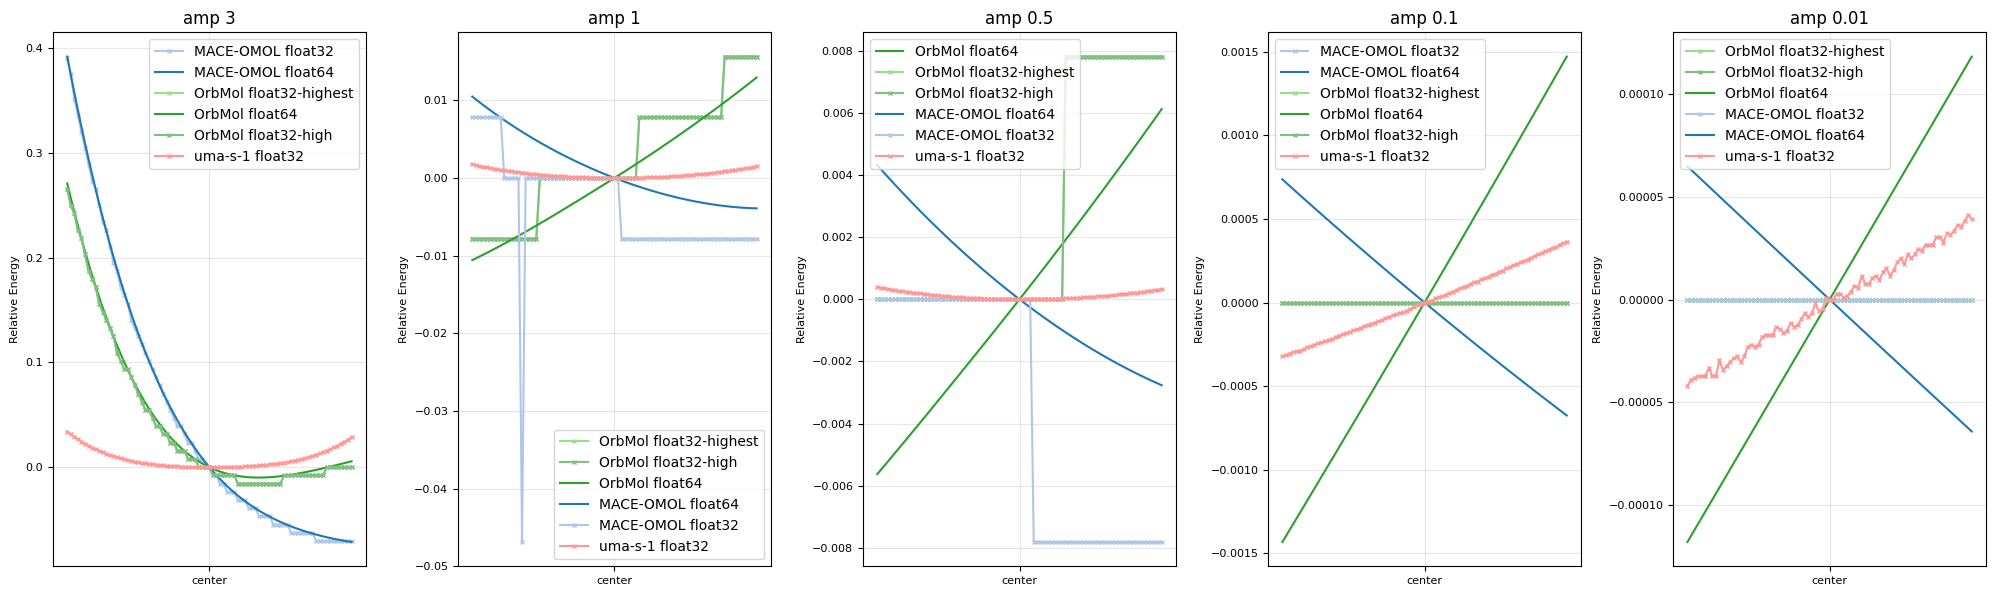

In [ ]:
plot_data()

In [ ]:
from ase.io import Trajectory
from aseview import viewer

traj = Trajectory("mode_idx_8_amp_0.5.traj")
viewer(traj[::10])
